### Definición de la Clase Generadora
En esta celda importamos las librerías necesarias (`numpy`, `matplotlib`, `sklearn`) y definimos una clase personalizada llamada `GeneradorCirculosConcentricos`.
Esta clase nos permitirá crear datasets sintéticos con estructuras no lineales, especificando:
* **n_samples:** Número total de puntos.
* **n_circles:** Cantidad de anillos concéntricos (clases).
* **noise:** Ruido añadido para dar realismo y dificultad al problema.
* **random_state:** Semilla para reproducibilidad.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA

class GeneradorCirculosConcentricos:
    def __init__(self, n_samples=600, n_circles=3, noise=0.05, random_state=None):
        """
        Generador de dataset sintético de circunferencias concéntricas

        Parámetros:
            n_samples (int): Número total de puntos
            n_circles (int): Número de circunferencias (clases)
            noise (float): Desviación estándar del ruido gaussiano
            random_state (int): Semilla para reproducibilidad
        """
        self.n_samples = n_samples
        self.n_circles = n_circles
        self.noise = noise
        self.random_state = random_state

    def generar_datos(self):
        if self.random_state:
            np.random.seed(self.random_state)

        n_samples_per_circle = self.n_samples // self.n_circles
        X_list = []
        y_list = []

        # Creamos radios equidistantes (ej: 0.2, 0.6, 1.0)
        radio = np.linspace(0.2, 1.0, self.n_circles)

        for i, r in enumerate(radio):
            # Generar ángulos de 0 a 2 * pi
            theta = np.linspace(0, 2 * np.pi, n_samples_per_circle, endpoint=False)

            # Coordenadas
            x = r * np.cos(theta)
            y = r * np.sin(theta)

            # Apilamos x e y
            circle_data = np.stack([x, y], axis=1)

            X_list.append(circle_data)
            # La etiqueta es el índice del círculo (0, 1, 2...)
            y_list.append(np.full(n_samples_per_circle, i))

        # Unimos todos los datos
        X = np.vstack(X_list)
        y = np.hstack(y_list)

        # Añadimos ruido aleatorio
        if self.noise:
            X += np.random.normal(scale=self.noise, size=X.shape)

        # Mezclamos los datos
        indices = np.random.permutation(len(X))
        return X[indices], y[indices]

### Generación del Dataset Sintético
Instanciamos nuestra clase para generar un problema de clasificación con **3 clases** (círculos concéntricos).
El resultado son dos arrays:
* `X`: Las coordenadas de los puntos.
* `y`: Las etiquetas de clase (0, 1, 2) a las que pertenece cada punto.

### Aplicación de Reducción de Dimensionalidad
Aquí comparamos dos técnicas para proyectar los datos:
1.  **PCA (Lineal):** Intenta encontrar ejes lineales de máxima varianza. Se espera que falle al separar datos concéntricos.
2.  **Kernel PCA (RBF):** Utiliza un "truco del kernel" (Radial Basis Function) para proyectar los datos a una dimensión superior implícita donde sí son linealmente separables, y luego los devuelve reducidos.

In [6]:
# Instanciamos nuestra clase y creamos el dataset
generador = GeneradorCirculosConcentricos(n_samples=600, n_circles=3, noise=0.05, random_state=42)
X, y = generador.generar_datos()

# Aplicamos PCA Lineal
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Aplicamos Kernel PCA (RBF)
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
X_kpca = kpca.fit_transform(X)

### Visualización Comparativa
Finalmente, generamos tres gráficos para analizar los resultados:
* **Espacio Original:** Muestra la estructura concéntrica de los datos.
* **PCA Lineal:** Muestra cómo los datos se superponen (mezcla de colores), confirmando que una proyección lineal no sirve.
* **Kernel PCA:** Muestra cómo el algoritmo ha logrado "desenrollar" o separar los anillos, haciendo las clases distinguibles.
* *Nota: Usamos una generación dinámica de colores y leyenda para soportar cualquier número de círculos.*

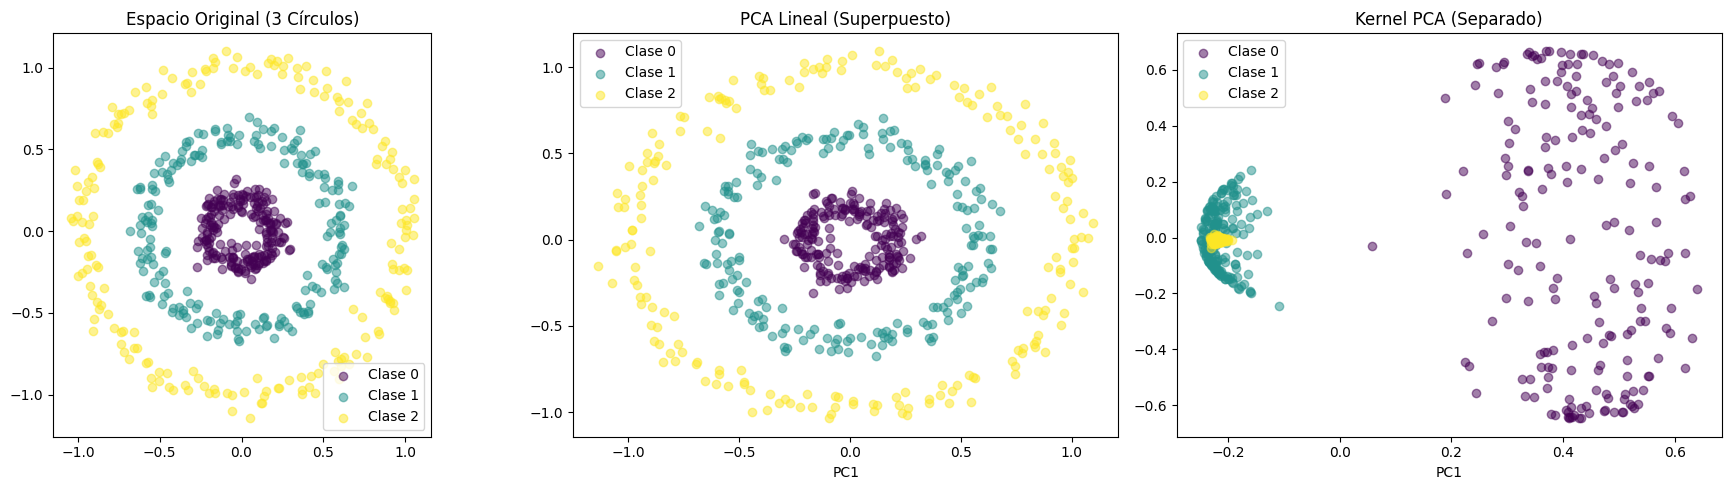

In [7]:
# Graficamos los resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.colormaps['viridis'].resampled(generador.n_circles) # Mapa de colores dinámico

# Función auxiliar para pintar según clases
def plot_scatter(axis, data, labels, title):
    for i in np.unique(labels):
        axis.scatter(data[labels==i, 0], data[labels==i, 1],
                     color=cmap(i), alpha=0.5, label=f'Clase {i}')
    axis.set_title(title)
    axis.legend()

# Original
plot_scatter(ax[0], X, y, "Espacio Original (3 Círculos)")
ax[0].set_aspect('equal')

# PCA Lineal
plot_scatter(ax[1], X_pca, y, "PCA Lineal (Superpuesto)")
ax[1].set_xlabel("PC1")

# Kernel PCA
plot_scatter(ax[2], X_kpca, y, "Kernel PCA (Separado)")
ax[2].set_xlabel("PC1")

plt.tight_layout()
plt.show()